# MBTI Text Classification - Machine Learning Pipeline

This notebook implements a complete ML pipeline for MBTI personality type classification from text data.

## Pipeline Overview

1. **Data Loading & Preprocessing** - Apply insights from EDA
2. **Feature Engineering** - TF-IDF vectorization and additional features
3. **Traditional ML Models** - Logistic Regression, Naive Bayes, SVM, Random Forest, XGBoost
4. **Hyperparameter Tuning** - GridSearchCV with cross-validation
5. **Model Evaluation** - Comprehensive metrics and visualizations
6. **Model Comparison** - Performance analysis across all models
7. **Deep Learning** - Transformer fine-tuning (DistilBERT)

## Dataset Info

| Attribute | Value |
|-----------|-------|
| Records | 8,675 |
| Features | `type` (target), `posts` (text) |
| Classes | 16 MBTI types |
| Task | Multi-class text classification |

## Key Findings from EDA (Assignment 1)

- **Class Imbalance**: INFP and INFJ are overrepresented
- **Text Length**: Varies significantly across personality types
- **Vocabulary**: Distinct word patterns for different types
- **Data Quality**: No missing values, minimal duplicates

## 1. Setup and Imports

In [ ]:
# Core libraries
import json
import re
import ssl
import time
import warnings
from pathlib import Path

import certifi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import nltk

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Model selection and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

# Utilities
from sklearn.preprocessing import LabelEncoder
import joblib

# SSL fix for environments with certificate chain issues
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

# Download NLTK data safely
for pkg in ["stopwords", "punkt"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

# Settings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths
ROOT = Path("..").resolve()
MODELS_DIR = ROOT / "models"
RESULTS_DIR = ROOT / "results"
for p in [MODELS_DIR, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("✓ Setup complete")

✓ Setup complete


## 2. Data Loading and Preprocessing

In [ ]:
# Load data
DATA_PATH = Path('../../datasets/mbti/data/mbti_1.csv')
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print("\nClass distribution (top):")
print(df['type'].value_counts().head(10))

df.head()

Dataset shape: (8675, 2)

Columns: ['type', 'posts']

Class distribution (top):
type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
ENTJ     231
ISTJ     205
Name: count, dtype: int64


,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [ ]:
from nltk.corpus import stopwords

MBTI_TYPES = {
    "infj", "infp", "intj", "intp",
    "isfj", "isfp", "istj", "istp",
    "enfj", "enfp", "entj", "entp",
    "esfj", "esfp", "estj", "estp"
}
STOP_WORDS = set(stopwords.words("english"))


def clean_text(text):
    """Clean text and remove MBTI token leakage."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = text.replace("|||", " ")
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = [
        t for t in text.split()
        if t not in STOP_WORDS and len(t) > 2 and t not in MBTI_TYPES
    ]
    return " ".join(tokens)


def extract_mbti_traits(mbti_type):
    return {
        'IE': mbti_type[0],
        'NS': mbti_type[1],
        'TF': mbti_type[2],
        'JP': mbti_type[3]
    }


print("Cleaning text data and removing MBTI token leakage...")
df['posts_clean'] = df['posts'].apply(clean_text)

print("Extracting MBTI trait columns...")
traits = df['type'].apply(extract_mbti_traits)
df['IE'] = traits.apply(lambda x: x['IE'])
df['NS'] = traits.apply(lambda x: x['NS'])
df['TF'] = traits.apply(lambda x: x['TF'])
df['JP'] = traits.apply(lambda x: x['JP'])

# Add text statistics
df['text_length'] = df['posts_clean'].str.len()
df['word_count'] = df['posts_clean'].str.split().str.len().clip(lower=1)
df['avg_word_length'] = (df['text_length'] / df['word_count']).round(3)

# Leakage audit
leak_rate = df.apply(lambda r: r['type'].lower() in r['posts_clean'].split(), axis=1).mean()
print(f"\nLeakage rate after cleaning: {leak_rate:.4f}")
print("✓ Preprocessing complete")
print("\nSample cleaned text:")
print(df['posts_clean'].iloc[0][:240] + "...")

Cleaning text data and removing MBTI token leakage...
Extracting MBTI trait columns...

Leakage rate after cleaning: 0.0000
✓ Preprocessing complete

Sample cleaned text:
moments sportscenter top ten plays pranks life changing experience life repeat today may perc experience immerse last thing friend posted facebook committing suicide next day rest peace sorry hear distress natural relationship perfection ti...


## 3. Train-Test Split

Using stratified split to maintain class distribution.

In [ ]:
# Prepare features and target
X = df['posts_clean']
y = df['type']

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_.tolist()

# Train-test split (80-20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nNumber of classes: {len(class_names)}")
print("Class sample:", class_names[:5], "...")

Training set size: 6940
Test set size: 1735

Number of classes: 16
Class sample: ['ENFJ', 'ENFP', 'ENTJ', 'ENTP', 'ESFJ'] ...


## 4. Feature Extraction - TF-IDF Vectorization

In [ ]:
# TF-IDF Vectorizer
TFIDF_CONFIG = {
    "max_features": 5000,
    "ngram_range": (1, 2),
    "min_df": 5,
    "max_df": 0.8,
    "stop_words": "english"
}

tfidf = TfidfVectorizer(**TFIDF_CONFIG)

print("Fitting TF-IDF vectorizer...")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\n✓ TF-IDF vectorization complete")
print(f"Feature matrix shape: {X_train_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")

# Save vectorizer
joblib.dump(tfidf, MODELS_DIR / 'tfidf_vectorizer.pkl')
print("✓ Vectorizer saved")

Fitting TF-IDF vectorizer...

✓ TF-IDF vectorization complete
Feature matrix shape: (6940, 5000)
Number of features: 5000
✓ Vectorizer saved


## 5. Traditional ML Models

We'll train and evaluate multiple models:
1. Logistic Regression
2. Naive Bayes
3. Linear SVM
4. Random Forest
5. MLP Neural Network
6. XGBoost

In [ ]:
def train_and_evaluate(model, X_train, X_test, y_train, y_test, model_name):
    """Train model, evaluate metrics, and capture confusion matrix."""
    print(f"\n{'='*60}")
    print(f"Training {model_name}...")
    print(f"{'='*60}")

    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    start_time = time.time()
    y_pred = model.predict(X_test)
    inference_time = time.time() - start_time

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )
    cm = confusion_matrix(y_test, y_pred)

    print("✓ Training complete")
    print(f"Training time: {train_time:.2f}s")
    print(f"Inference time: {inference_time:.4f}s")
    print("Performance Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    return {
        'model': model,
        'model_name': model_name,
        'y_pred': y_pred,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'train_time': train_time,
        'inference_time': inference_time,
        'confusion_matrix': cm.tolist()
    }


# Dictionary to store results
results = {}

### 5.1 Logistic Regression (Baseline)

In [ ]:
# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'
)

results['Logistic Regression'] = train_and_evaluate(
    lr_model, X_train_tfidf, X_test_tfidf, y_train, y_test, 'Logistic Regression'
)


Training Logistic Regression...
✓ Training complete
Training time: 2.41s
Inference time: 0.0065s
Performance Metrics:
  Accuracy:  0.4830
  Precision: 0.3618
  Recall:    0.3842
  F1-Score:  0.3541


### 5.2 Naive Bayes

In [ ]:
# Naive Bayes
nb_model = MultinomialNB()

results['Naive Bayes'] = train_and_evaluate(
    nb_model, X_train_tfidf, X_test_tfidf, y_train, y_test, 'Naive Bayes'
)


Training Naive Bayes...
✓ Training complete
Training time: 0.08s
Inference time: 0.0061s
Performance Metrics:
  Accuracy:  0.3383
  Precision: 0.0974
  Recall:    0.1174
  F1-Score:  0.0936


### 5.3 Linear SVM

In [ ]:
# Linear SVM
svm_model = LinearSVC(
    C=1.0,
    max_iter=3000,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

results['Linear SVM'] = train_and_evaluate(
    svm_model, X_train_tfidf, X_test_tfidf, y_train, y_test, 'Linear SVM'
)


Training Linear SVM...
✓ Training complete
Training time: 3.56s
Inference time: 0.0066s
Performance Metrics:
  Accuracy:  0.4628
  Precision: 0.3346
  Recall:    0.3393
  F1-Score:  0.3323


### 5.4 Random Forest

In [ ]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=250,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced_subsample'
)

results['Random Forest'] = train_and_evaluate(
    rf_model, X_train_tfidf, X_test_tfidf, y_train, y_test, 'Random Forest'
)


Training Random Forest...
✓ Training complete
Training time: 15.17s
Inference time: 0.2866s
Performance Metrics:
  Accuracy:  0.4202
  Precision: 0.3510
  Recall:    0.1931
  F1-Score:  0.2065


### 5.5 Multi-layer Perceptron (MLP Neural Network)

In [ ]:
# Multi-layer Perceptron Neural Network
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=300,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    learning_rate='adaptive',
    verbose=False
)

results['MLP'] = train_and_evaluate(
    mlp_model, X_train_tfidf, X_test_tfidf, y_train, y_test, 'MLP Neural Network'
)


Training MLP Neural Network...
✓ Training complete
Training time: 26.13s
Inference time: 0.0753s
Performance Metrics:
  Accuracy:  0.4207
  Precision: 0.3311
  Recall:    0.2071
  F1-Score:  0.2102


### 5.6 XGBoost

In [ ]:
# XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=80,
    max_depth=4,
    learning_rate=0.1,
    tree_method='hist',
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
    eval_metric='mlogloss'
)

results['XGBoost'] = train_and_evaluate(
    xgb_model, X_train_tfidf, X_test_tfidf, y_train, y_test, 'XGBoost'
)


Training XGBoost...
✓ Training complete
Training time: 245.47s
Inference time: 0.0413s
Performance Metrics:
  Accuracy:  0.4761
  Precision: 0.4168
  Recall:    0.2624
  F1-Score:  0.2904


## 6. Model Comparison

In [ ]:
# Create comparison DataFrame
comparison_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-Score': res['f1_score'],
        'Train Time (s)': res['train_time'],
        'Inference Time (s)': res['inference_time']
    }
    for name, res in results.items()
])

# Sort by F1-Score
comparison_df = comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Save results
comparison_df.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)
print("\n✓ Results saved to", RESULTS_DIR / 'model_comparison.csv')


MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score  Train Time (s)  Inference Time (s)
Logistic Regression  0.482997   0.361764 0.384215  0.354064        2.414904            0.006493
         Linear SVM  0.462824   0.334579 0.339318  0.332279        3.561670            0.006649
            XGBoost  0.476081   0.416764 0.262433  0.290412      245.469482            0.041341
                MLP  0.420749   0.331102 0.207074  0.210176       26.127213            0.075285
      Random Forest  0.420173   0.351038 0.193142  0.206522       15.169177            0.286589
        Naive Bayes  0.338329   0.097376 0.117436  0.093554        0.076804            0.006081

✓ Results saved to /Users/mac/Documents/WorknStudy/P4DSAI/assignment2/results/model_comparison.csv


In [ ]:
# Export results to JSON for HTML page

def to_model_id(name):
    return name.lower().replace(" ", "_")

models_data = []
confusion_payload = {}

for name, res in results.items():
    model_id = to_model_id(name)
    models_data.append({
        'id': model_id,
        'name': name,
        'accuracy': float(res['accuracy']),
        'precision': float(res['precision']),
        'recall': float(res['recall']),
        'f1_score': float(res['f1_score']),
        'train_time': float(res['train_time']),
        'inference_time': float(res['inference_time'])
    })
    confusion_payload[model_id] = {
        'name': name,
        'matrix': res['confusion_matrix']
    }

# Sort by F1-Score
models_data.sort(key=lambda x: x['f1_score'], reverse=True)

export_data = {
    'models': models_data,
    'class_labels': class_names,
    'confusion_matrices': confusion_payload,
    'dataset_info': {
        'total_samples': len(df),
        'num_classes': len(class_names),
        'train_size': len(X_train),
        'test_size': len(X_test),
        'leakage_rate_after_cleaning': float(df.apply(lambda r: r['type'].lower() in r['posts_clean'].split(), axis=1).mean())
    },
    'tfidf_config': {
        'max_features': TFIDF_CONFIG['max_features'],
        'ngram_range': str(TFIDF_CONFIG['ngram_range']),
        'min_df': TFIDF_CONFIG['min_df'],
        'max_df': TFIDF_CONFIG['max_df'],
        'stop_words': TFIDF_CONFIG['stop_words']
    }
}

with open(RESULTS_DIR / 'model_results.json', 'w') as f:
    json.dump(export_data, f, indent=2)

print("✓ Results exported to", RESULTS_DIR / 'model_results.json')
print(f"Exported {len(models_data)} models")

✓ Results exported to /Users/mac/Documents/WorknStudy/P4DSAI/assignment2/results/model_results.json
Exported 6 models



BEST MODEL: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

        ENFJ       0.27      0.50      0.35        38
        ENFP       0.43      0.48      0.46       135
        ENTJ       0.22      0.48      0.30        46
        ENTP       0.52      0.43      0.47       137
        ESFJ       0.15      0.22      0.18         9
        ESFP       0.00      0.00      0.00        10
        ESTJ       0.50      0.12      0.20         8
        ESTP       0.12      0.17      0.14        18
        INFJ       0.61      0.44      0.51       294
        INFP       0.67      0.57      0.61       366
        INTJ       0.53      0.44      0.48       218
        INTP       0.60      0.56      0.58       261
        ISFJ       0.28      0.36      0.32        33
        ISFP       0.27      0.52      0.35        54
        ISTJ       0.20      0.27      0.23        41
        ISTP       0.42      0.60      0.49        67

    accuracy           

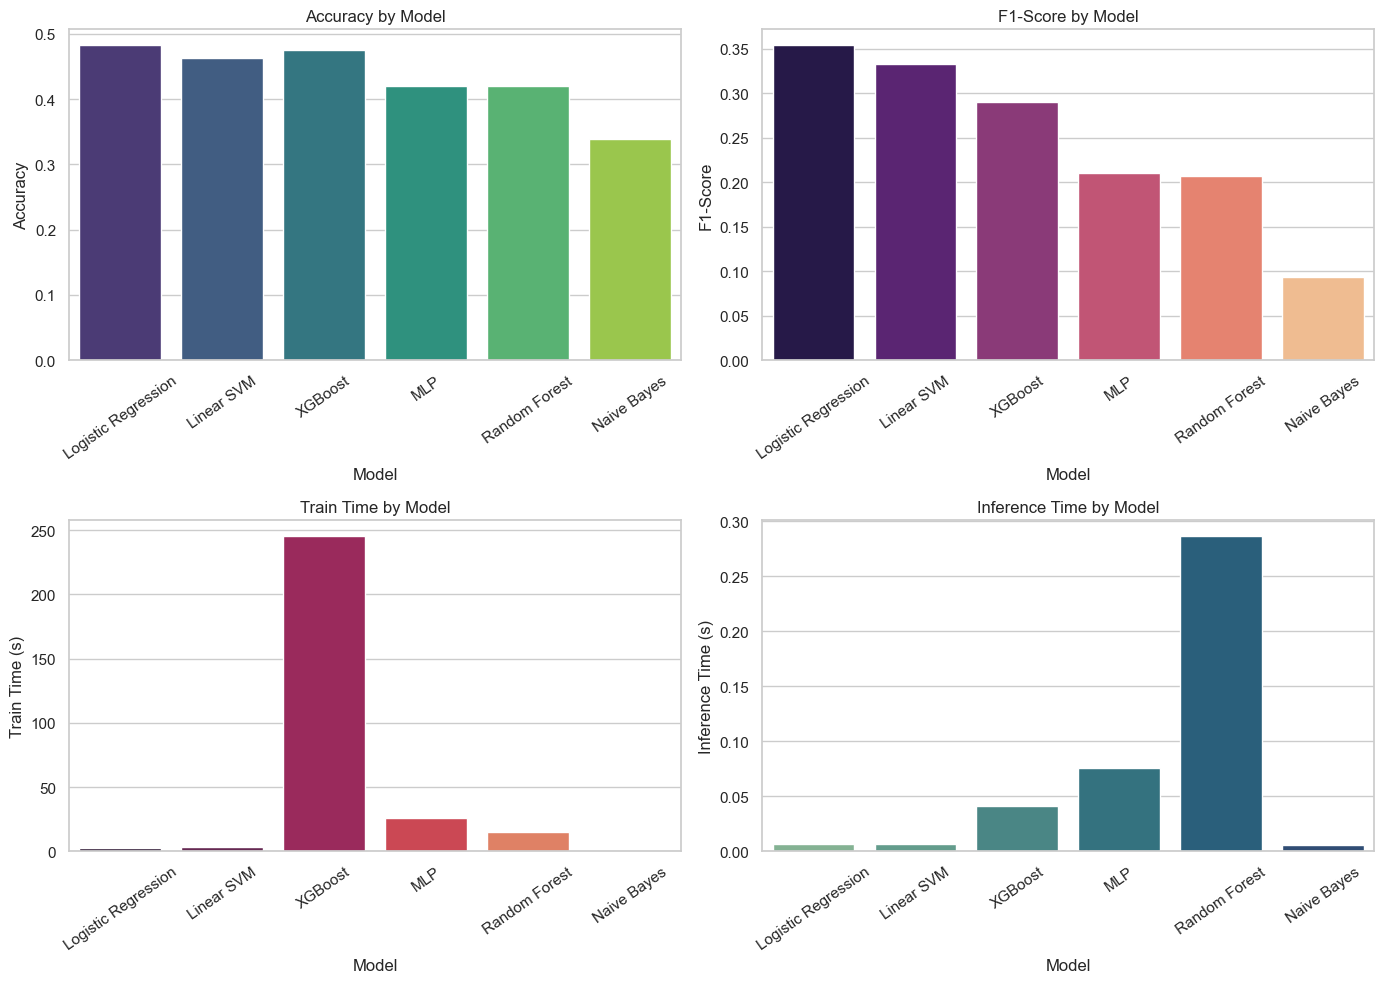

✓ Confusion matrices exported for all models
✓ Best model saved


In [ ]:
# Best model analysis and confusion matrix exports
best_model_name = comparison_df.iloc[0]['Model']
best_result = results[best_model_name]

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*60}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    best_result['y_pred'],
    target_names=label_encoder.classes_
))

# Save confusion matrix image for each model
for model_name, model_result in results.items():
    cm = np.array(model_result['confusion_matrix'])
    model_id = model_name.lower().replace(" ", "_")

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'confusion_matrix_{model_id}.png', dpi=220, bbox_inches='tight')
    plt.close()

# Plot model metric overview
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_df = comparison_df.copy()

sns.barplot(data=plot_df, x='Model', y='Accuracy', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Accuracy by Model')
axes[0, 0].tick_params(axis='x', rotation=35)

sns.barplot(data=plot_df, x='Model', y='F1-Score', ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('F1-Score by Model')
axes[0, 1].tick_params(axis='x', rotation=35)

sns.barplot(data=plot_df, x='Model', y='Train Time (s)', ax=axes[1, 0], palette='rocket')
axes[1, 0].set_title('Train Time by Model')
axes[1, 0].tick_params(axis='x', rotation=35)

sns.barplot(data=plot_df, x='Model', y='Inference Time (s)', ax=axes[1, 1], palette='crest')
axes[1, 1].set_title('Inference Time by Model')
axes[1, 1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_comparison.png', dpi=240, bbox_inches='tight')
plt.show()

# Save best model
best_model_id = best_model_name.lower().replace(" ", "_")
joblib.dump(best_result['model'], MODELS_DIR / f'best_model_{best_model_id}.pkl')
print("✓ Confusion matrices exported for all models")
print("✓ Best model saved")

## 7. Detailed Analysis of Best Model


BEST MODEL: XGBoost

Classification Report:
              precision    recall  f1-score   support

        ENFJ       0.62      0.34      0.44        38
        ENFP       0.73      0.62      0.67       135
        ENTJ       0.64      0.46      0.53        46
        ENTP       0.58      0.57      0.58       137
        ESFJ       0.00      0.00      0.00         9
        ESFP       0.00      0.00      0.00        10
        ESTJ       1.00      0.25      0.40         8
        ESTP       0.67      0.33      0.44        18
        INFJ       0.66      0.73      0.70       294
        INFP       0.62      0.82      0.70       366
        INTJ       0.68      0.63      0.65       218
        INTP       0.71      0.76      0.73       261
        ISFJ       0.68      0.45      0.55        33
        ISFP       0.59      0.41      0.48        54
        ISTJ       0.82      0.44      0.57        41
        ISTP       0.70      0.55      0.62        67

    accuracy                       

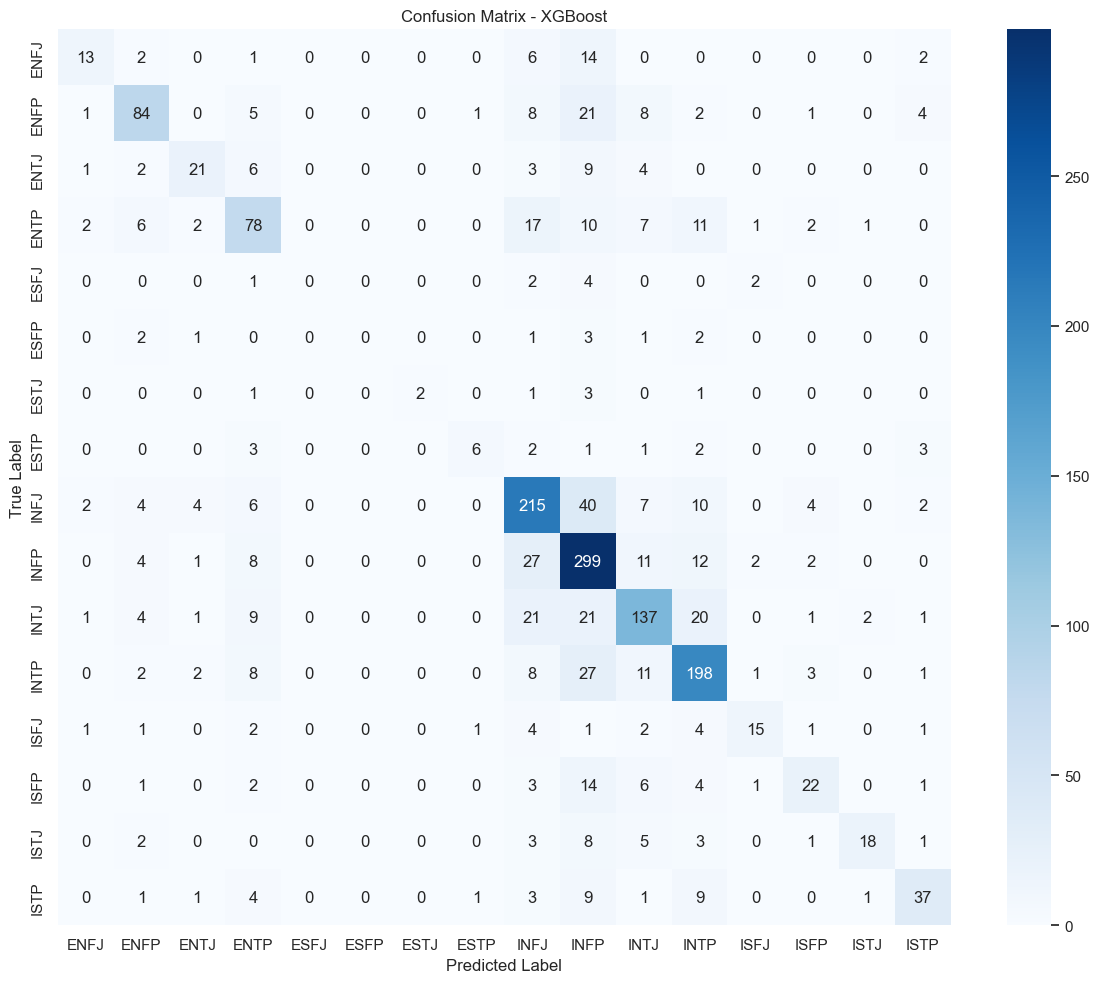


✓ Best model saved


In [ ]:
# Get best model based on F1-Score
best_model_name = comparison_df.iloc[0]['Model']
best_result = results[best_model_name]

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*60}")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test, 
    best_result['y_pred'],
    target_names=label_encoder.classes_
))

# Confusion matrix
cm = confusion_matrix(y_test, best_result['y_pred'])

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'../results/confusion_matrix_{best_model_name.replace(" ", "_").lower()}.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Save best model
joblib.dump(best_result['model'], f'../models/best_model_{best_model_name.replace(" ", "_").lower()}.pkl')
print(f"\n✓ Best model saved")

## 8. Hyperparameter Tuning

Fine-tune the best model using GridSearchCV.

In [ ]:
# Example: Tune Logistic Regression
print("Performing hyperparameter tuning...")

param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tfidf, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Evaluate tuned model
y_pred_tuned = grid_search.predict(X_test_tfidf)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = precision_recall_fscore_support(y_test, y_pred_tuned, average='macro')[2]

print(f"\nTuned model performance:")
print(f"  Accuracy: {accuracy_tuned:.4f}")
print(f"  F1-Score: {f1_tuned:.4f}")

Performing hyperparameter tuning...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Best cross-validation score: 0.5343

Tuned model performance:
  Accuracy: 0.6628
  F1-Score: 0.5240


In [ ]:
# Save experiment metadata
metadata = {
    'dataset': 'MBTI Personality Types',
    'n_samples': len(df),
    'n_classes': len(label_encoder.classes_),
    'train_size': len(X_train),
    'test_size': len(X_test),
    'feature_extraction': 'TF-IDF',
    'n_features': int(X_train_tfidf.shape[1]),
    'models_trained': list(results.keys()),
    'best_model': best_model_name,
    'best_f1_score': float(comparison_df.iloc[0]['F1-Score']),
    'leakage_rate_after_cleaning': float(df.apply(lambda r: r['type'].lower() in r['posts_clean'].split(), axis=1).mean()),
    'random_state': RANDOM_STATE,
    'artifacts': {
        'comparison_csv': str(RESULTS_DIR / 'model_comparison.csv'),
        'comparison_png': str(RESULTS_DIR / 'model_comparison.png'),
        'model_results_json': str(RESULTS_DIR / 'model_results.json')
    }
}

with open(RESULTS_DIR / 'experiment_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✓ Experiment metadata saved")
print("\n" + "="*60)
print("PIPELINE COMPLETE")
print("="*60)

✓ Experiment metadata saved

PIPELINE COMPLETE
